In [ ]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import regex as re
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from nltk.corpus import stopwords, names
import nltk

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package names to /root/nltk_data...
[nltk_data]   Package names is already up-to-date!


In [ ]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('names')

# Define stopwords, name lists, and unwanted titles
stop_words = set(stopwords.words('english'))
unwanted_titles = {'mr', 'mrs', 'ms', 'dr', 'jr', 'sr', 'miss', 'rev'}
human_name_list = set(name.lower() for name in names.words())

# Load datasets
df = pd.read_csv("/content/test — копия.csv")
val_df = pd.read_csv("/content/train — копия.csv")

In [ ]:
# Split labeled data
person_rows = df[df['label'] == 1]
org_rows = df[df['label'] == 0]

# Tokenize and clean individual names
person_tokens = person_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
filtered_person_names = [
    name for sublist in person_tokens for name in sublist
    if name not in stop_words
    and name not in unwanted_titles
    and len(name) > 1
    and name in human_name_list
]
top_names = [name for name, _ in Counter(filtered_person_names).most_common(10)]

# Tokenize and clean organization words
org_tokens = org_rows['full_name'].dropna().apply(lambda x: re.findall(r'\b\w+\b', x.lower()))
filtered_org_words = [
    word for sublist in org_tokens for word in sublist
    if word not in stop_words
    and word not in unwanted_titles
    and word not in top_names
    and len(word) > 1
]
top_org_words = [word for word, _ in Counter(filtered_org_words).most_common(15)]

['committee',
 'elect',
 'pac',
 'inc',
 'friends',
 'arizona',
 'campaign',
 'llc',
 'senate',
 'state',
 'az',
 'congress',
 'county',
 'republican',
 'pa']

In [ ]:

# Feature functions
def is_pac(full_name, pac_words):
    """Returns 1 if name includes any common PAC words."""
    if not isinstance(full_name, str):
        return 0
    return int(any(token in pac_words for token in re.findall(r'\b\w+\b', full_name.lower())))

def is_org(full_name, org_words):
    """Returns 1 if name includes any common org words."""
    if not isinstance(full_name, str):
        return 0
    return int(any(token in org_words for token in re.findall(r'\b\w+\b', full_name.lower())))

def count_name(full_name):
    """Returns the number of words in a full name."""
    return len(str(full_name).split())

In [ ]:
# Add features to df
df['is_pac_name'] = df['full_name'].apply(lambda x: is_pac(x, top_names))
df['is_org_name'] = df['full_name'].apply(lambda x: is_org(x, top_org_words))
df['name_length'] = df['full_name'].apply(count_name)

In [ ]:
# Fit on train names
vectorizer = TfidfVectorizer()
vectorizer.fit(val_df['full_name'])  # Fit on actual training set

# Transform both sets
X_train = vectorizer.transform(val_df['full_name'])  # Training set
X_val = vectorizer.transform(df['full_name'])        # Validation set

# Labels
y_train = val_df['label']
y_val = df['label']

In [ ]:
# Train SVC model
svc = SVC(random_state=42, C=1, gamma=1)
svc.fit(X_train, y_train)

# Predict on validation set
predicted_y = svc.predict(X_val)

In [ ]:
# Evaluate model
accuracy = accuracy_score(y_val, predicted_y) * 100
recall = recall_score(y_val, predicted_y) * 100
precision = precision_score(y_val, predicted_y) * 100
f1 = f1_score(y_val, predicted_y) * 100

# Print results
print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("f1_score:", f1)
print()
print(classification_report(y_val, predicted_y))

Accuracy: 87.94299136854272
Recall: 89.44524160035779
Precision: 86.84458114709608
f1_score: 88.12572865890043

              precision    recall  f1-score   support

           0       0.89      0.86      0.88     53619
           1       0.87      0.89      0.88     53663

    accuracy                           0.88    107282
   macro avg       0.88      0.88      0.88    107282
weighted avg       0.88      0.88      0.88    107282



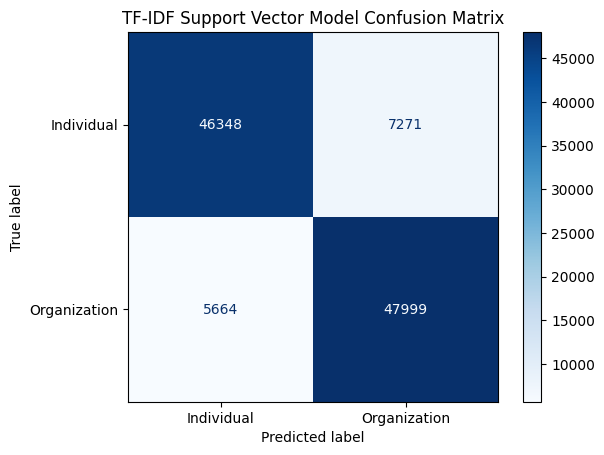

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_val, predicted_y, labels=[0, 1])

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Individual', 'Organization'])
disp.plot(cmap=plt.cm.Blues)

# Add title and show
plt.title('TF-IDF Support Vector Model Confusion Matrix')
plt.show()

In [ ]:
# Load test dataset
test_df = pd.read_csv("/content/test — копия.csv")

# Transform full_name column using trained TF-IDF vectorizer
X_test = vectorizer.transform(test_df['full_name'])

# Load test labels from training file
y_test = train_df['label']

In [ ]:
# Predict on test set
predicted_y_test = svc.predict(X_test)

# Print classification metrics
print(classification_report(y_test, predicted_y_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     15329
           1       1.00      1.00      1.00     15323

    accuracy                           1.00     30652
   macro avg       1.00      1.00      1.00     30652
weighted avg       1.00      1.00      1.00     30652

